Dataset Information

Dataset Used:
Speech Commands Dataset (TensorFlow Datasets)

The dataset contains short one-second recordings of spoken words such as "yes", "no", "up", "down", and "left". Only a small number of samples are loaded directly from TensorFlow Datasets for this experiment to reduce storage usage.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from transformers import Wav2Vec2Processor
from transformers import Wav2Vec2Model

import torch

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances

In [4]:
import datasets
print(datasets.__version__)

5.0.1


In [5]:
!pip uninstall datasets -y

Found existing installation: datasets 5.0.1
Uninstalling datasets-5.0.1:
  Successfully uninstalled datasets-5.0.1


In [8]:
!pip install datasets==3.6.0

In [10]:
import datasets
print(datasets.__version__)

5.0.1


In [1]:
import datasets
print(datasets.__version__)

3.6.0


In [1]:
import datasets
import transformers
import huggingface_hub

print("datasets:", datasets.__version__)
print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 3.6.0
transformers: 4.46.3
huggingface_hub: 0.36.2


In [5]:
from datasets import load_dataset

dataset = load_dataset(
    "speech_commands",
    "v0.02",
    split="train[:10]",
    trust_remote_code=True
)

print(dataset)

Generating train split:   0%|          | 0/84848 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9982 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4890 [00:00<?, ? examples/s]

Dataset({
    features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
    num_rows: 10
})


In [7]:
print(dataset[0])

{'file': 'backward/2356b88d_nohash_0.wav', 'audio': {'path': 'backward/2356b88d_nohash_0.wav', 'array': array([ 0.        ,  0.        ,  0.        , ..., -0.00012207,
       -0.00015259, -0.00012207], shape=(16000,)), 'sampling_rate': 16000}, 'label': 30, 'is_unknown': True, 'speaker_id': '2356b88d', 'utterance_id': 0}


In [8]:
import IPython.display as ipd

audio_sample = dataset[0]["audio"]["array"]

sampling_rate = dataset[0]["audio"]["sampling_rate"]

print("Audio length:", len(audio_sample))
print("Sampling Rate:", sampling_rate)

ipd.Audio(
    audio_sample,
    rate=sampling_rate
)

Audio length: 16000
Sampling Rate: 16000


Pretrained Audio Model

In this project, Wav2Vec2, a pretrained speech representation model from Hugging Face, is used to extract embeddings from audio clips. The model converts raw audio waveforms into meaningful feature vectors that can be compared for similarity.

In [9]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import torch


# Load pretrained Wav2Vec2 processor
processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)


# Load pretrained Wav2Vec2 model
model = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base-960h"
)


print("Wav2Vec2 model loaded successfully")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

D:\Anaconda\envs\opencv-env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--facebook--wav2vec2-base-960h. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Wav2Vec2 model loaded successfully


Feature Extraction

The pretrained model is used only for inference. Each audio clip is passed through Wav2Vec2 to obtain an embedding vector. These embeddings represent the audio characteristics and are later used for similarity comparison.

In [10]:
import numpy as np


embeddings = []

audio_labels = []


for sample in dataset:

    # Get audio waveform
    audio = sample["audio"]["array"]

    # Get sampling rate
    sr = sample["audio"]["sampling_rate"]


    # Convert audio into model input format
    inputs = processor(
        audio,
        sampling_rate=sr,
        return_tensors="pt"
    )


    # Disable training because we only need inference
    with torch.no_grad():

        output = model(**inputs)


    # Average hidden states to create one embedding vector
    embedding = output.last_hidden_state.mean(dim=1)


    embeddings.append(
        embedding.squeeze().numpy()
    )


    audio_labels.append(
        sample["label"]
    )


print("Embeddings extracted successfully")

Embeddings extracted successfully


In [11]:
embeddings = np.array(embeddings)

print(embeddings.shape)

(10, 768)


Similarity Calculation

Cosine similarity is used to measure how close two audio embeddings are. Higher values indicate that two audio clips have similar acoustic features.

In [12]:
from sklearn.metrics.pairwise import cosine_similarity


# Calculate cosine similarity between all audio clips

similarity_matrix = cosine_similarity(
    embeddings
)


print("Similarity Matrix:")
print(similarity_matrix)

Similarity Matrix:
[[1.         0.9610938  0.9216391  0.923205   0.9190115  0.9343599
  0.9525428  0.9350742  0.94436204 0.9168346 ]
 [0.9610938  0.9999999  0.9073916  0.89723766 0.91970515 0.91676664
  0.9340684  0.92720294 0.9611312  0.88709503]
 [0.9216391  0.9073916  1.         0.82978034 0.911777   0.8444771
  0.9227847  0.90920067 0.91381824 0.8161504 ]
 [0.923205   0.89723766 0.82978034 0.9999999  0.83622336 0.9890852
  0.9019098  0.88717115 0.8794305  0.99105   ]
 [0.9190115  0.91970515 0.911777   0.83622336 1.0000001  0.855409
  0.89021313 0.90967834 0.9470905  0.8425586 ]
 [0.9343599  0.91676664 0.8444771  0.9890852  0.855409   0.9999999
  0.9153825  0.9015602  0.8922392  0.98169553]
 [0.9525428  0.9340684  0.9227847  0.9019098  0.89021313 0.9153825
  1.0000004  0.9529497  0.9134618  0.892599  ]
 [0.9350742  0.92720294 0.90920067 0.88717115 0.90967834 0.9015602
  0.9529497  0.99999976 0.9028063  0.8834377 ]
 [0.94436204 0.9611312  0.91381824 0.8794305  0.9470905  0.8922392
  

Compute Distance Scores

In [13]:
from sklearn.metrics.pairwise import euclidean_distances


# Calculate distance between embeddings

distance_matrix = euclidean_distances(
    embeddings
)


print("Distance Matrix:")
print(distance_matrix)

Distance Matrix:
[[0.         1.2441694  1.7450364  2.8518553  1.7666086  2.501889
  1.5655788  1.7915591  1.4647472  2.7564132 ]
 [1.2441694  0.         1.9114112  3.074446   1.7741607  2.6602228
  1.8012912  1.8806998  1.2384927  3.0174413 ]
 [1.7450364  1.9114112  0.         3.6708846  1.8341312  3.339581
  1.9465456  2.0897524  1.8123909  3.6263206 ]
 [2.8518553  3.074446   3.6708846  0.         3.6332474  0.9666433
  2.8505445  3.0133405  3.2883759  0.86330146]
 [1.7666086  1.7741607  1.8341312  3.6332474  0.         3.2624555
  2.2870529  2.0886884  1.4124296  3.4341915 ]
 [2.501889   2.6602228  3.339581   0.9666433  3.2624555  0.
  2.507997   2.672356   2.9502602  1.1759384 ]
 [1.5655788  1.8012912  1.9465456  2.8505445  2.2870529  2.507997
  0.         1.5365102  2.0540748  2.8274071 ]
 [1.7915591  1.8806998  2.0897524  3.0133405  2.0886884  2.672356
  1.5365102  0.         2.1591916  2.9274385 ]
 [1.4647472  1.2384927  1.8123909  3.2883759  1.4124296  2.9502602
  2.0540748  2.

Visualize Similarity Heatmap

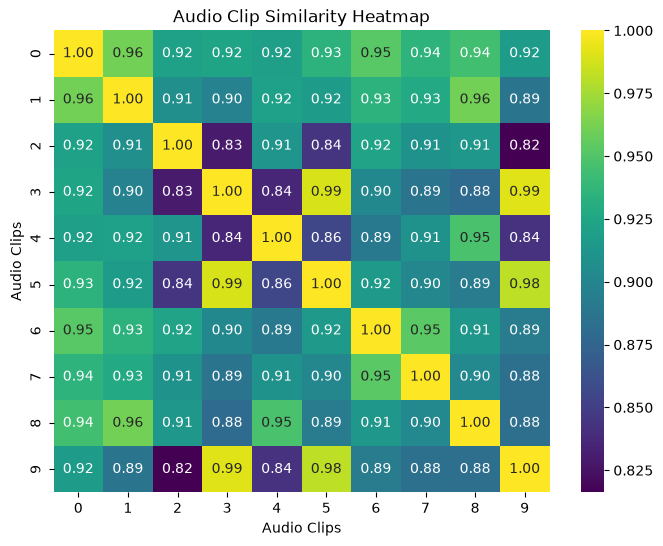

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,6))


sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)


plt.title("Audio Clip Similarity Heatmap")

plt.xlabel("Audio Clips")

plt.ylabel("Audio Clips")


plt.show()

Distance Matrix

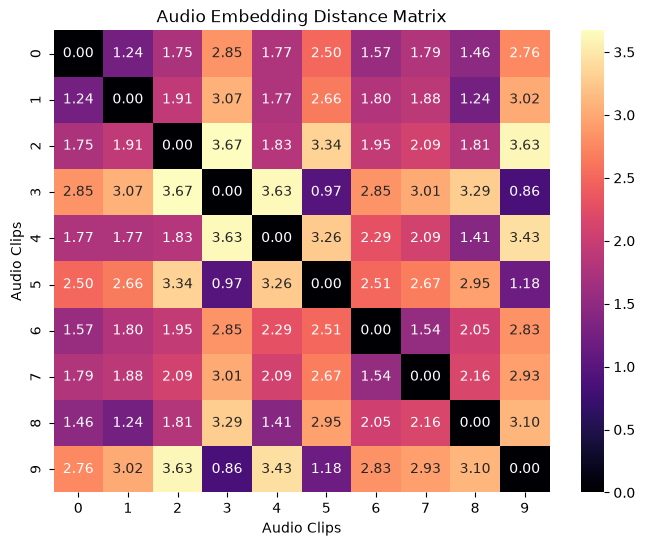

In [15]:
plt.figure(figsize=(8,6))


sns.heatmap(
    distance_matrix,
    annot=True,
    fmt=".2f",
    cmap="magma"
)


plt.title("Audio Embedding Distance Matrix")

plt.xlabel("Audio Clips")

plt.ylabel("Audio Clips")


plt.show()

In [16]:
for i, sample in enumerate(dataset):
    
    print(
        "Audio Clip:",
        i,
        "| File:",
        sample["file"],
        "| Label:",
        sample["label"]
    )

Audio Clip: 0 | File: backward/2356b88d_nohash_0.wav | Label: 30
Audio Clip: 1 | File: backward/3291330e_nohash_3.wav | Label: 30
Audio Clip: 2 | File: backward/b91b718c_nohash_3.wav | Label: 30
Audio Clip: 3 | File: backward/85851131_nohash_1.wav | Label: 30
Audio Clip: 4 | File: backward/244cc3a5_nohash_0.wav | Label: 30
Audio Clip: 5 | File: backward/2927c601_nohash_4.wav | Label: 30
Audio Clip: 6 | File: backward/18e910f4_nohash_3.wav | Label: 30
Audio Clip: 7 | File: backward/9151f184_nohash_2.wav | Label: 30
Audio Clip: 8 | File: backward/86f3558f_nohash_0.wav | Label: 30
Audio Clip: 9 | File: backward/ef3367d9_nohash_6.wav | Label: 30


Dataset Information

The Speech Commands dataset contains short speech recordings of different spoken words from multiple speakers. In this project, a small subset of 10 audio clips was used to reduce storage requirements and demonstrate audio similarity analysis.

Model Information

A pretrained Wav2Vec2 model was used to extract audio embeddings. The model converts raw speech signals into meaningful feature representations that help compare similarities between audio clips.